# wavdetect


In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
The CIAO setup for this window has changed from
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3
To:
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 578
download_chandra_obsid 578
chandra_repro 578 out=`pwd` clob+


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      10 Kb  ####################          < 1 s  521.7 kb/s
  oif      fits       25 Kb  ####################          < 1 s  707.0 kb/s
  vv       pdf        46 Kb  ####################          < 1 s  1080.7 kb/s
  cntr_img fits      129 Kb  ####################          < 1 s  10686.0 kb/s
  cntr_img jpg       575 Kb  ####################          < 1 s  8793.1 kb/s
  evt2     fits       10 Mb  ####################          < 1 s  46939.5 kb/s
  full_img fits       76 Kb  ####################          < 1 s  8219.2 kb/s
  full_img jpg        69 Kb  ####################          < 1 s  8354.6 kb/s
  src2     fits       13 Kb  ####################          < 1 s  2191.1 kb/s
  src_img  jpg        71 Kb  ####################          < 1 s  8613.4 kb/s
  bpix     fits       19 Kb  ####################          < 1 

In [3]:
dmcopy "acisf00578_repro_fov1.fits[ccd_id=7]" s3.fov clob+
dmcopy "acisf00578_repro_evt2.fits[ccd_id=7,sky=region(s3.fov)]" 578_evt2_filtered.fits clob+

In [4]:
fluximage 578_evt2_filtered.fits binsize=1 bands=broad outroot=s3 clob+

Running fluximage
Version: 12 September 2016

Using CSC ACIS broad science energy band.
Aspect solution pcadf052378346N003_asol1.fits found.
Bad-pixel file acisf00578_repro_bpix1.fits found.
Mask file acisf00578_000N003_msk1.fits found.

The output images will have 1390 by 1389 pixels, pixel size of 0.492 arcsec,
    and cover x=3506.5:4896.5:1,y=3676.5:5065.5:1.

Running tasks in parallel with 4 processors.
Creating aspect histogram for obsid 578
Creating instrument map for obsid 578
Creating exposure map for obsid 578
Thresholding data for obsid 578
Exposure-correcting image for obsid 578

The following files were created:

 The clipped counts image is:
     s3_broad_thresh.img

 The clipped exposure map is:
     s3_broad_thresh.expmap

 The exposure-corrected image is:
     s3_broad_flux.img



In [5]:
dmlist s3_broad_thresh.img blocks

 
--------------------------------------------------------------------------------
Dataset: s3_broad_thresh.img
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: EVENTS_IMAGE                   Image      Int4(1390x1389)


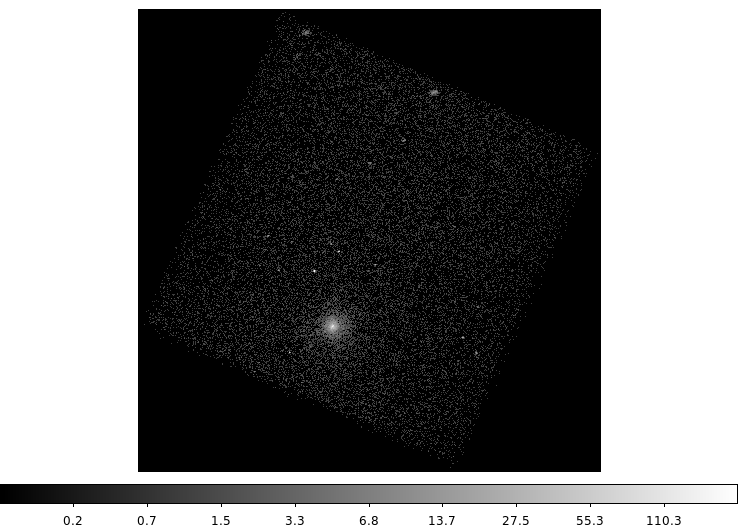

In [6]:
ds9 s3_broad_thresh.img \
  -block 3 \
  -scale log \
  -saveimage png ds9_01.png -quit

display < ds9_01.png

## psfmap

In [7]:
mkpsfmap s3_broad_thresh.img outfile=s3_psfmap.fits energy=1.4967 ecf=0.393 clob+

## A. Simple Example

In [8]:
punlearn wavdetect
pset wavdetect infile=s3_broad_thresh.img
pset wavdetect psffile=s3_psfmap.fits

pset wavdetect outfile=s3_src.fits
pset wavdetect scellfile=s3_scell.fits
pset wavdetect imagefile=s3_imgfile.fits
pset wavdetect defnbkgfile=s3_nbgd.fits
pset wavdetect regfile=s3_src.reg
wavdetect mode=h clobber=yes


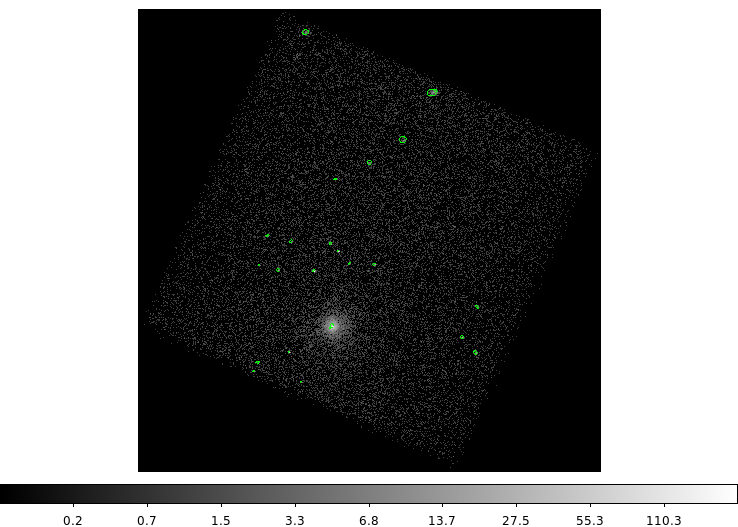

In [9]:
ds9 s3_broad_thresh.img \
  -block 3 \
  -scale log \
  -region s3_src.fits \
  -saveimage png ds9_02.png -quit

display < ds9_02.png

In [10]:
punlearn wavdetect
pset wavdetect infile=s3_broad_thresh.img
pset wavdetect psffile=s3_psfmap.fits

pset wavdetect outfile=as3_src.fits
pset wavdetect scellfile=as3_scell.fits
pset wavdetect imagefile=as3_imgfile.fits
pset wavdetect defnbkgfile=as3_nbgd.fits
pset wavdetect regfile=as3_src.reg

pset wavdetect scales="1.0 2.0 4.0 8.0 16.0"
pset wavdetect sigthresh=4e-06
wavdetect mode=h clobber=yes



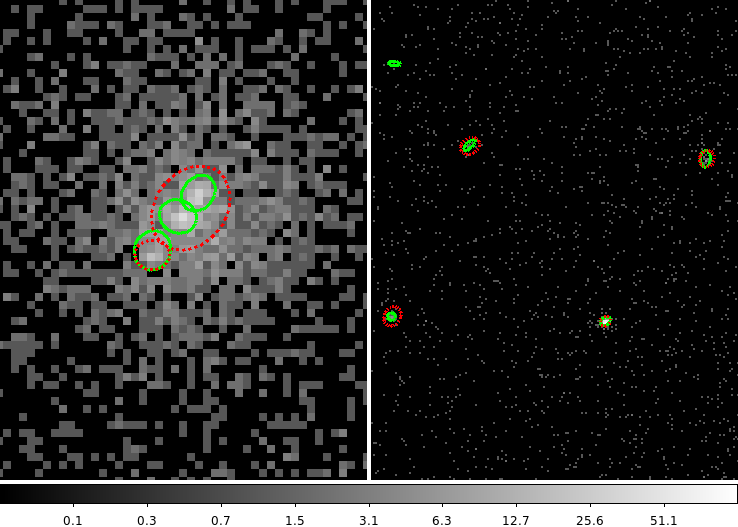

In [11]:
ds9 s3_broad_thresh.img \
  -pan to 4090 4110 physical \
  -zoom 8 \
  -scale log \
  -region width 3 \
  -region s3_src.fits \
  -region select all \
  -region color red \
  -region background \
  -region select none \
  -region color green \
  -region source \
  -region as3_src.fits \
  -region select all -region copy -region select none\
  s3_broad_thresh.img \
  -region paste wcs \
  -zoom 0.25 \
  -pan to 4010 4320 \
  -saveimage png ds9_03.png -quit

display < ds9_03.png

## With expmap

In [12]:
punlearn wavdetect
pset wavdetect infile=s3_broad_thresh.img
pset wavdetect psffile=s3_psfmap.fits
pset wavdetect expfile=s3_broad_thresh.expmap

pset wavdetect outfile=s3_expmap_src.fits
pset wavdetect scellfile=s3_expmap_scell.fits
pset wavdetect imagefile=s3_expmap_imgfile.fits
pset wavdetect defnbkgfile=s3_expmap_nbgd.fits
pset wavdetect regfile=s3_expmap_src.reg
wavdetect mode=h clobber=yes

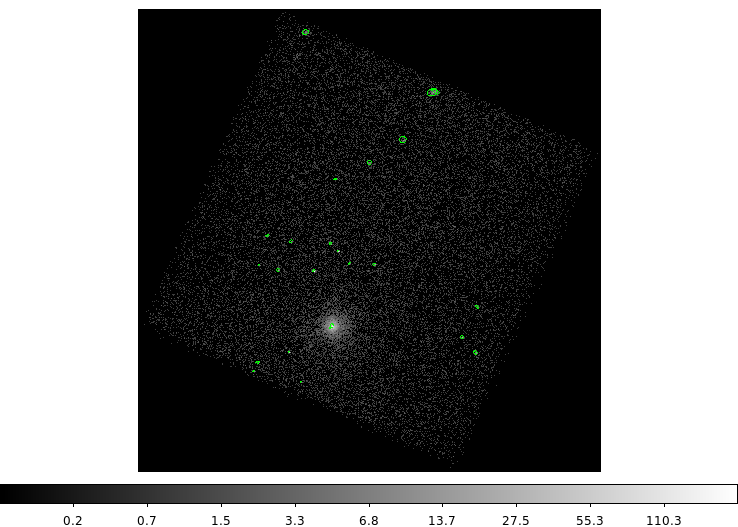

In [13]:
ds9 s3_broad_thresh.img \
  -block 3 \
  -scale log \
  -region s3_expmap_src.fits \
  -saveimage png ds9_04.png -quit

display < ds9_04.png

In [14]:
dmlist "s3_expmap_src.fits[cols RA,DEC,PSF_SIZE]" data

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    RA                   DEC                  PSF_SIZE
 
     1       212.8558082470        52.1797510905     0.59262645244598
     2       212.8873156967        52.1842945463     0.87103253602982
     3       212.8846619199        52.1879422299     0.77664190530777
     4       212.7390553283        52.1919239772         1.7067636251
     5       212.8639873148        52.1921472650     0.55221420526505
     6       212.7480868048        52.1982449530         1.3846766949
     7       212.8362121844        52.2021179328     0.46548777818680
     8       212.8351420862        52.2029166406     0.46837383508682
     9       212.8474580223        52.2255283779     0.69639825820923
    10       212.8712238187        52.2258457804     0.85530811548233
    11       212.8839016950        52.2277505

[1] 5054
[1]+  Done                    prism s3_expmap_src.fits


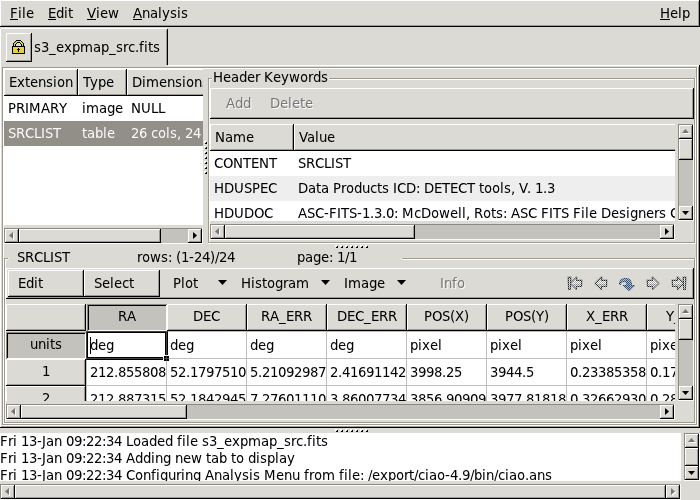

In [15]:
prism s3_expmap_src.fits &
sleep 3
import -window prism prism.png
xpaset -p prism quit
display < prism.png